In [74]:
import numpy as np

import matplotlib.pyplot as plt 

In [75]:
# Input features
# Column 1 = Study Hours
# Column 2 = Attendance

X = np.array([
    [1, 40],
    [2, 50],
    [3, 55],
    [4, 60],
    [5, 70],
    [6, 75],
    [7, 80],
    [8, 90]
], dtype=float)


# Target values
# 0 = Fail
# 1 = Pass

y = np.array([
    0,
    0,
    0,
    0,
    1,
    1,
    1,
    1
], dtype=float)


print("Input Features:")
print(X)

print("\nTarget:")
print(y)

Input Features:
[[ 1. 40.]
 [ 2. 50.]
 [ 3. 55.]
 [ 4. 60.]
 [ 5. 70.]
 [ 6. 75.]
 [ 7. 80.]
 [ 8. 90.]]

Target:
[0. 0. 0. 0. 1. 1. 1. 1.]


In [76]:
print(X.shape)
print(y.shape)

(8, 2)
(8,)


In [77]:
# ## Step 2: Normalize the Data

# Our two features have different ranges.

# Study Hours:
# 1 to 8

# Attendance:
# 40 to 90

# We scale them so that both features have smaller and comparable values.

# This helps the model learn more efficiently.

# Divide study hours by 10
# Divide attendance by 100

X = X / np.array([10, 100])

print(X)

[[0.1  0.4 ]
 [0.2  0.5 ]
 [0.3  0.55]
 [0.4  0.6 ]
 [0.5  0.7 ]
 [0.6  0.75]
 [0.7  0.8 ]
 [0.8  0.9 ]]


## Step 3: Weights

Each input has a weight.

We have two inputs:

x1 = Study Hours
x2 = Attendance

Therefore we need two weights:

w1 = Weight for Study Hours
w2 = Weight for Attendance

The model learns these weights during training.

In [78]:
# Set a random seed so that we get the same random values
# every time we run the notebook.

np.random.seed(42)

# Create 2 random weights
# One weight for each input feature

weights = np.random.randn(2)

print("Initial Weights:", weights)

Initial Weights: [ 0.49671415 -0.1382643 ]


## Step 4: Bias

Bias is an additional value that helps the neuron shift
the decision boundary.

The basic neuron calculation is:

z = (x1 × w1) + (x2 × w2) + bias

In [79]:
bias =  0.0
print("Initial Bias:", bias)

Initial Bias: 0.0


## Step 5: Perceptron

A perceptron takes inputs, multiplies them by weights,
adds the bias, and produces an output.

Formula:

z = x1*w1 + x2*w2 + b

In matrix form:

z = XW + b

In [80]:
z= np.dot(X,weights) + bias
print("weighted Sum:")
print(z)

weighted Sum:
[-0.00563431  0.03021068  0.07296888  0.11572708  0.15157207  0.19433027
  0.23708847  0.27293345]


## Step 6: Activation Function

The weighted sum can be any number.

For example:

- -5
- -2
- 0
- 2
- 5

We want an output between 0 and 1.

Therefore we use the Sigmoid activation function.

Sigmoid:

1 / (1 + e^-x)

The output can be interpreted as probability.

In [81]:
# Define Sigmoid activation function

def sigmoid(x):
    return 1/(1+np.exp(-x))

In [82]:
print(sigmoid(-5))

print(sigmoid(0))

print(sigmoid(5))

0.0066928509242848554
0.5
0.9933071490757153


In [83]:
# Apply sigmoid to the weighted sum

prediction = sigmoid(z)

print("prediction: ")
print(prediction)

prediction: 
[0.49859143 0.5075521  0.51823413 0.52889952 0.53782064 0.54843025
 0.55899602 0.56781292]


## Step 7: Convert Probability to Class

We use 0.5 as the threshold.

If:

prediction >= 0.5 → Pass = 1

prediction < 0.5 → Fail = 0

In [84]:
# Convert probabilities into 0 or 1

final_prediction = (prediction >=0.5).astype(int)
print("final_prediction")
print(final_prediction)

final_prediction
[0 1 1 1 1 1 1 1]


In [85]:
print("\nActual:")
print(y)


Actual:
[0. 0. 0. 0. 1. 1. 1. 1.]


## Step 8: Loss Function

The model made predictions.

Now we need to calculate:

"How wrong is the model?"

This is the job of the Loss Function.

For binary classification we can use:

Binary Cross Entropy Loss

Low loss  → Good prediction
High loss → Bad prediction

In [86]:
def binary_cross_entropy(y, prediction):
    # Small value to prevent log(0)
    epsilon = 1e-8
    # Binary Cross Entropy formula
    loss = -np.mean(
        y * np.log(prediction + epsilon)
        + (1 - y) * np.log(1 - prediction + epsilon)
    )
    
    return loss



In [87]:
loss= binary_cross_entropy(y,prediction)
print("Loss", loss)

Loss 0.6562728611646029


## Step 9: Backward Propagation

Forward propagation:

Input → Prediction

But now we know the prediction is not perfect.

We need to answer:

"How should we change the weights?"

Backward propagation works backward from the loss.

Flow:

Prediction
    ↓
Loss
    ↓
Gradient
    ↓
Weight Update

The gradients tell us how much each parameter
contributed to the error.

In [88]:
# For sigmoid + binary cross entropy, we can calculate:
# dz = prediction - actual

dz = prediction - y

print("Gradient dz:")
print(dz)

Gradient dz:
[ 0.49859143  0.5075521   0.51823413  0.52889952 -0.46217936 -0.45156975
 -0.44100398 -0.43218708]


## Step 10: Calculate Weight Gradients

We need to know how much each weight should change.

We calculate:

dw = gradient of loss with respect to weights

In [89]:
# number of training examples 

m= len(y)

#calculate gradient for weights

dw= np.dot(X.T, dz)/m

print("Weight Gredients:")
print(dw)


Weight Gredients:
[-0.07976055 -0.04354916]


In [90]:
# Calculate gradient for bias

db= np.mean(dz)
print("Bias Gradient:")
print(db)

Bias Gradient:
0.033292126059692395


 dw → How weights should change

 db → How bias should change

### Step 11: Gradient Descent

Now we update the weights and bias.

Formula:

new_weight =
old_weight - learning_rate × gradient

The learning rate controls how big each update is.

Small learning rate:
Slow learning

Large learning rate:
Can become unstable



In [91]:
# Learning rate

learning_rate = 0.1


# Update weights

weights = weights - learning_rate * dw


# Update bias

bias = bias - learning_rate * db


print("Updated Weights:", weights)
print("Updated Bias:", bias)

Updated Weights: [ 0.50469021 -0.13390938]
Updated Bias: -0.00332921260596924


In [92]:
# ==========================================
# FORWARD PROPAGATION
# ==========================================

# Weighted sum
z = np.dot(X, weights) + bias

# Activation
prediction = sigmoid(z)


# ==========================================
# LOSS
# ==========================================

loss = binary_cross_entropy(y, prediction)


# ==========================================
# BACKWARD PROPAGATION
# ==========================================

dz = prediction - y

dw = np.dot(X.T, dz) / len(y)

db = np.mean(dz)


# ==========================================
# GRADIENT DESCENT
# ==========================================

weights = weights - learning_rate * dw

bias = bias - learning_rate * db


print("Loss:", loss)
print("Weights:", weights)
print("Bias:", bias)

Loss: 0.6553381494456851
Weights: [ 0.51261778 -0.1296137 ]
Bias: -0.006734783716285759


## Step 12: Training for Multiple Epochs

One update is not enough.

We repeat the process many times.

Each complete iteration over the dataset is called an epoch.

Example:

Epoch 1
→ Prediction
→ Loss
→ Backpropagation
→ Update

Epoch 2
→ Prediction
→ Loss
→ Backpropagation
→ Update

...

Epoch 1000
→ Prediction
→ Loss
→ Backpropagation
→ Update

In [93]:
# Reset weights and bias

np.random.seed(42)

weights = np.random.randn(2)

bias = 0.0

learning_rate = 0.1

epochs = 1000


# Store loss values so that we can plot them

loss_history = []

In [94]:
for epoch in range(epochs):

    # ======================================
    # FORWARD PROPAGATION
    # ======================================

    # Calculate weighted sum
    z = np.dot(X, weights) + bias

    # Apply activation function
    prediction = sigmoid(z)


    # ======================================
    # CALCULATE LOSS
    # ======================================

    loss = binary_cross_entropy(y, prediction)

    # Store loss
    loss_history.append(loss)


    # ======================================
    # BACKWARD PROPAGATION
    # ======================================

    # Gradient with respect to z
    dz = prediction - y

    # Gradient with respect to weights
    dw = np.dot(X.T, dz) / len(y)

    # Gradient with respect to bias
    db = np.mean(dz)


    # ======================================
    # GRADIENT DESCENT
    # ======================================

    # Update weights
    weights = weights - learning_rate * dw

    # Update bias
    bias = bias - learning_rate * db


    # Print loss every 100 epochs

    if (epoch + 1) % 100 == 0:
        print(
            f"Epoch {epoch + 1}, "
            f"Loss: {loss:.4f}"
        )

        

Epoch 100, Loss: 0.5791
Epoch 200, Loss: 0.5185
Epoch 300, Loss: 0.4703
Epoch 400, Loss: 0.4314
Epoch 500, Loss: 0.3995
Epoch 600, Loss: 0.3729
Epoch 700, Loss: 0.3506
Epoch 800, Loss: 0.3315
Epoch 900, Loss: 0.3149
Epoch 1000, Loss: 0.3005


## The important thing is that loss should generally decrease.
## Step 13: Visualize Training

We stored the loss after every epoch.

Now we can see whether the model is learning.

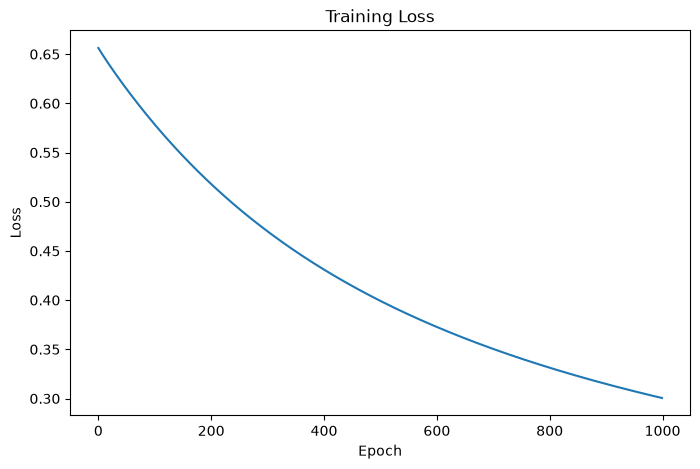

In [95]:
plt.figure(figsize=(8,5))
plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training Loss")
plt.show()

In [96]:
# Calculate final weighted sum

z = np.dot(X, weights) + bias


# Calculate final probabilities

final_probability = sigmoid(z)


# Convert probabilities to classes

final_prediction = (
    final_probability >= 0.5
).astype(int)


print("Final Predictions:")
print(final_prediction)

print("\nActual Values:")
print(y.astype(int))

Final Predictions:
[0 0 0 0 1 1 1 1]

Actual Values:
[0 0 0 0 1 1 1 1]


In [97]:
for i in range(len(X)):

    print(
        f"Student: {i+1}:"
        f"Probability = {final_probability[i]:.3f},"
        f"probabilty={final_prediction[i]},"
        f"Actual = {int(y[i])}"
        
    )

Student: 1:Probability = 0.117,probabilty=0,Actual = 0
Student: 2:Probability = 0.204,probabilty=0,Actual = 0
Student: 3:Probability = 0.313,probabilty=0,Actual = 0
Student: 4:Probability = 0.447,probabilty=0,Actual = 0
Student: 5:Probability = 0.611,probabilty=1,Actual = 1
Student: 6:Probability = 0.736,probabilty=1,Actual = 1
Student: 7:Probability = 0.832,probabilty=1,Actual = 1
Student: 8:Probability = 0.906,probabilty=1,Actual = 1


In [98]:
# Calculate accuracy

accuracy= np.mean(final_prediction==y)

print("accuracy", accuracy)

print("Accuracy Percentage:", accuracy * 100, "%")


accuracy 1.0
Accuracy Percentage: 100.0 %


In [100]:
# New student ############################### TESTING PURPOSE #########################################

new_student = np.array([7, 85], dtype=float)


# Normalize using the same scaling
# that we used during training

new_student = new_student / np.array([10, 100])


# Forward propagation

z = np.dot(new_student, weights) + bias


# Activation

probability = sigmoid(z)


# Final prediction

prediction = 1 if probability >= 0.5 else 0


print("Pass Probability:", probability)
print("Prediction:", prediction)

Pass Probability: 0.8441576537792632
Prediction: 1
